# Real-Time Optimization and Delay Forecasting in Smart Supply Chains 

## Project Overview

This project focuses on analyzing and optimizing a smart logistics supply chain using real-world-inspired sensor and shipment data. Our goal is to detect factors contributing to logistics delays and propose actionable improvements.

### Key Goals:
1. **Geospatial Analysis** – Identify delay hotspots using latitude/longitude data.
2. **Exploratory Data Analysis (EDA)** – Explore relationships among traffic status, waiting time, asset utilization, and shipment delays.
3. **Predictive Modeling** – Build and evaluate a classification model to predict logistics delays.
4. **Operational Optimization** – Recommend data-driven improvements to reduce delays and improve efficiency.

### Tools Used:
- Python, pandas, seaborn, matplotlib, folium
- Scikit-learn (Random Forest Classifier)
- Data visualization and geospatial mapping

The dataset used in this analysis can be found in the following link: https://www.kaggle.com/datasets/ziya07/smart-logistics-supply-chain-dataset?resource=download

In [23]:
# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Geospatial mapping
# ==============================================================================
import folium
import geopandas

# Machine Learning 
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Importing the data 
# ==============================================================================
df = pd.read_csv('smart_logistics_dataset.csv')
display(df.shape)
display(df.columns)
display(df.dtypes)
display(df.head())
display(df.tail())

(1000, 16)

Index(['Timestamp', 'Asset_ID', 'Latitude', 'Longitude', 'Inventory_Level',
       'Shipment_Status', 'Temperature', 'Humidity', 'Traffic_Status',
       'Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency',
       'Logistics_Delay_Reason', 'Asset_Utilization', 'Demand_Forecast',
       'Logistics_Delay'],
      dtype='object')

Timestamp                   object
Asset_ID                    object
Latitude                   float64
Longitude                  float64
Inventory_Level              int64
Shipment_Status             object
Temperature                float64
Humidity                   float64
Traffic_Status              object
Waiting_Time                 int64
User_Transaction_Amount      int64
User_Purchase_Frequency      int64
Logistics_Delay_Reason      object
Asset_Utilization          float64
Demand_Forecast              int64
Logistics_Delay              int64
dtype: object

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,NaN,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1
2,2024-07-29 18:42:48,Truck_10,54.9232,79.5455,190,In Transit,25.2,62.2,Detour,34,355,3,NaN,99.2,260,0
3,2024-10-28 00:50:54,Truck_9,42.3900,-1.4788,330,Delivered,25.4,52.3,Heavy,37,227,5,Traffic,97.4,160,1
4,2024-09-27 15:52:58,Truck_7,-65.8477,47.9468,480,Delayed,20.5,57.2,Clear,56,197,6,NaN,71.6,270,1


,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
995,2024-07-22 16:30:00,Truck_6,89.8701,73.6867,264,Delivered,26.9,70.0,Heavy,32,188,1,Weather,79.2,213,1
996,2024-04-30 04:58:58,Truck_5,-10.4792,-177.1239,479,Delivered,23.7,77.9,Detour,56,276,7,Weather,83.7,272,0
997,2024-10-27 22:09:13,Truck_2,-71.0609,75.3714,347,In Transit,21.0,63.1,Detour,35,382,5,NaN,74.8,275,0
998,2024-04-18 23:06:56,Truck_2,-76.7910,18.3631,276,Delivered,18.0,64.3,Heavy,10,361,5,NaN,88.6,242,1
999,2024-09-18 19:39:24,Truck_8,59.8356,-114.4198,157,Delayed,18.7,73.6,Clear,55,323,9,Mechanical Failure,81.3,141,1


## EDA Analysis

In this section, we explore the structure and patterns in the dataset to understand key drivers of logistics delays. We begin by inspecting for missing values and then perform univariate and bivariate analyses.

### Key Steps:
- Identified and filled missing values in `Logistics_Delay_Reason` with `'None'`
- Confirmed data completeness across all other fields
- Previewed dataset structure to verify column types and distributions

This sets the stage for detailed visual exploration of traffic conditions, waiting times, asset utilization, and their relationship with shipment delays.

In [24]:
# Check NaN values
# ==============================================================================
display(df.isna().sum())

# Change 'NaN' values to 'None'
# ==============================================================================
df['Logistics_Delay_Reason'] = df['Logistics_Delay_Reason'].fillna('None')

# Display dataset 
# ==============================================================================
display(df.isna().sum())

display(df.head(2))

Timestamp                    0
Asset_ID                     0
Latitude                     0
Longitude                    0
Inventory_Level              0
Shipment_Status              0
Temperature                  0
Humidity                     0
Traffic_Status               0
Waiting_Time                 0
User_Transaction_Amount      0
User_Purchase_Frequency      0
Logistics_Delay_Reason     263
Asset_Utilization            0
Demand_Forecast              0
Logistics_Delay              0
dtype: int64

Timestamp                  0
Asset_ID                   0
Latitude                   0
Longitude                  0
Inventory_Level            0
Shipment_Status            0
Temperature                0
Humidity                   0
Traffic_Status             0
Waiting_Time               0
User_Transaction_Amount    0
User_Purchase_Frequency    0
Logistics_Delay_Reason     0
Asset_Utilization          0
Demand_Forecast            0
Logistics_Delay            0
dtype: int64

,Timestamp,Asset_ID,Latitude,Longitude,Inventory_Level,Shipment_Status,Temperature,Humidity,Traffic_Status,Waiting_Time,User_Transaction_Amount,User_Purchase_Frequency,Logistics_Delay_Reason,Asset_Utilization,Demand_Forecast,Logistics_Delay
0,2024-03-20 00:11:14,Truck_7,-65.7383,11.2497,390,Delayed,27.0,67.8,Detour,38,320,4,None,60.1,285,1
1,2024-10-30 07:53:51,Truck_6,22.2748,-131.7086,491,In Transit,22.5,54.3,Heavy,16,439,7,Weather,80.9,174,1


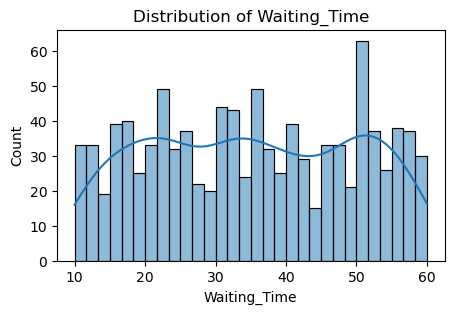

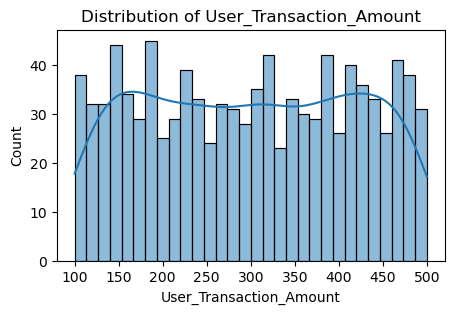

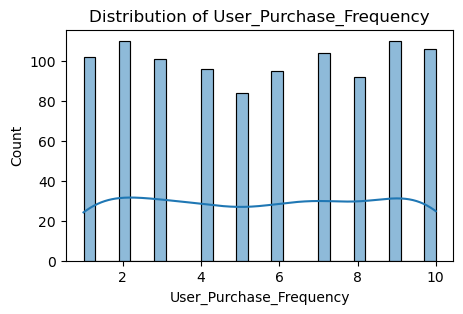

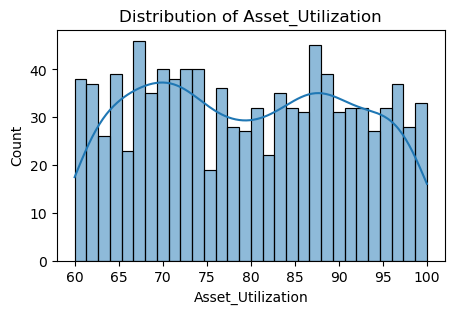

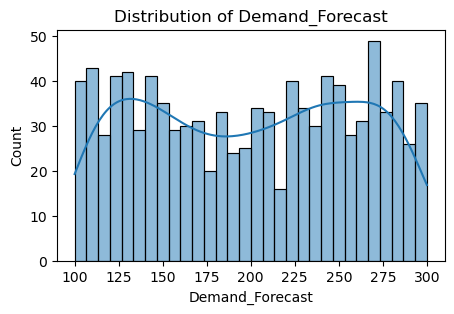

In [26]:
# Check for distribution of numerical values: Understand how your numerical data is spread and identify any skew or outliers.
# ==============================================================================
num_cols = ['Waiting_Time', 'User_Transaction_Amount', 'User_Purchase_Frequency',
            'Asset_Utilization', 'Demand_Forecast']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

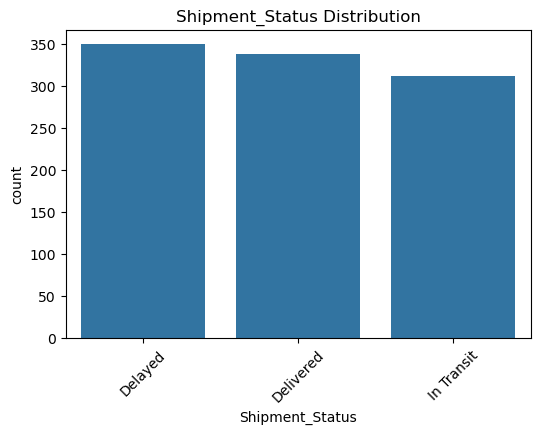

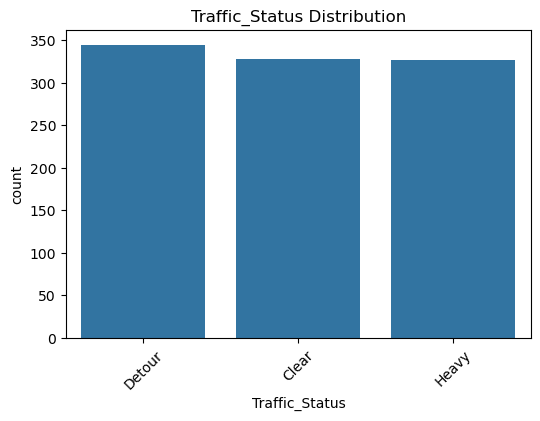

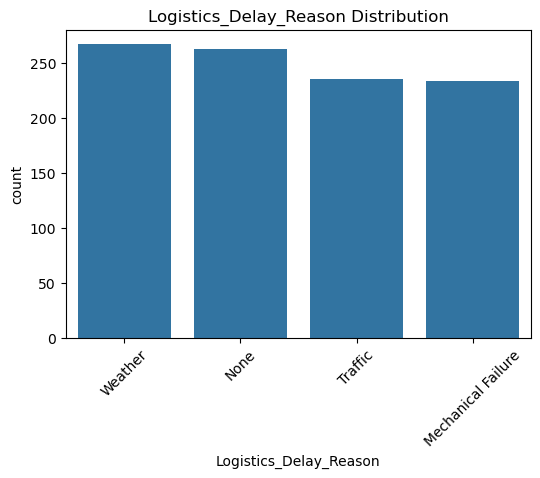

In [20]:
# Categorical Breakdown: How frequent are categories? Who's causing delays?
# ==============================================================================
cat_cols = ['Shipment_Status', 'Traffic_Status', 'Logistics_Delay_Reason']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

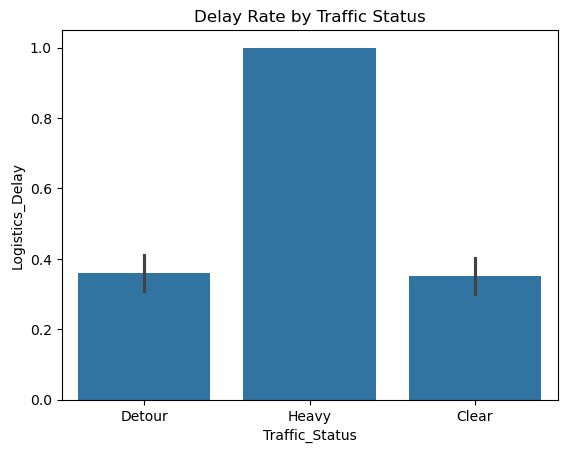

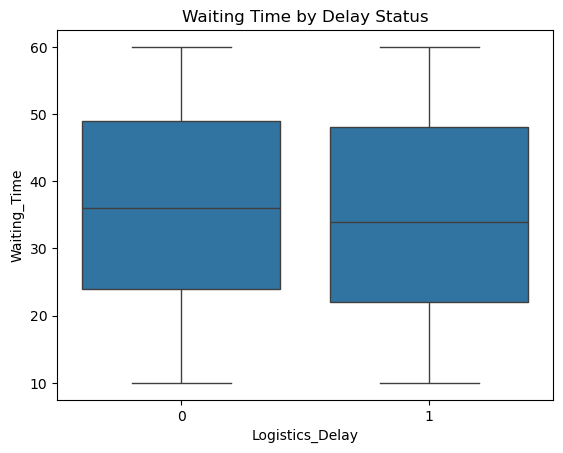

In [21]:
# Target Variables: Understand how each feature correlates with delays (Logistics_Delay)
# ==============================================================================

# Delay rate per Traffic_Status
# ==============================================================================
sns.barplot(x='Traffic_Status', y='Logistics_Delay', data=df)
plt.title("Delay Rate by Traffic Status")
plt.show()

# Boxplot: Waiting Time vs Delay
# ==============================================================================
sns.boxplot(x='Logistics_Delay', y='Waiting_Time', data=df)
plt.title("Waiting Time by Delay Status")
plt.show()

**Numerical Features**:
- All numerical features (Waiting Time, Utilization, Demand Forecast, etc.) appear fairly uniformly distributed — a good base for ML models.
- No heavy skew or obvious outliers, which means minimal transformations needed.

**Categorical Insights**:
- Shipment Status is fairly balanced across Delayed, Delivered, and In Transit.
- Traffic Status is also well-distributed.
- Delay Reasons are most commonly Weather and None, with Traffic and Mechanical Failure also significant.

**Correlation with Delays**:
- Heavy traffic clearly leads to a much higher probability of delay — very predictive!
- Waiting Time has a wide range for both delay/no-delay, so it may not be a strong standalone predictor.

In [30]:
from folium.plugins import HeatMap
from IPython.display import display

# Geospatial Heatmap
# ==============================================================================

# Filter Data for the Heatmap
# ==============================================================================
delay_data = df[df['Logistics_Delay']== 1] # Only rows with delay data
heat_data = delay_data[['Latitude', 'Longitude']].values.tolist() # Extract just the coordinates as a list of [lat, lon]

# Create a Folium map: We center the map on the average coordinates of the delayed shipments
# ==============================================================================
lat_center = df['Latitude'].mean()
lon_center = df['Longitude'].mean()

m = folium.Map(location=[lat_center, lon_center], zoom_start=6)

# Add the HeatMap layer
# ==============================================================================
HeatMap(heat_data, radius=10).add_to(m)

# Save and view the map
# ==============================================================================
display(m)
m.save("logistics_delay_heatmap.html")

## Machine Learning Modelling

In this section, we build a supervised classification model to predict whether a logistics shipment will be delayed based on operational and environmental data.

### Key Steps:
- Selected top-performing features from EDA and feature importance analysis
- Encoded categorical variables using `LabelEncoder` (suitable for tree-based models)
- Performed a train-test split to ensure generalization
- Trained a `RandomForestClassifier` with custom hyperparameters and evaluated its performance using:
  - Out-of-Bag (OOB) score
  - Confusion matrix
  - Classification metrics (precision, recall, f1-score)
- Visualized feature importance to interpret which variables most influence delays

This model helps logistics teams proactively flag likely delays and take preventive action based on key drivers such as traffic status, asset utilization, and demand forecast.

In [40]:
# Set the response variable and the predictor variables respectively
# ==============================================================================
y = df['Logistics_Delay']
X = df[['Traffic_Status',
        'Demand_Forecast', 
       'User_Transaction_Amount', 
       'Asset_Utilization']].copy()

# Label encode categorical features
# ==============================================================================
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['Traffic_Status'] = le.fit_transform(X['Traffic_Status'])

# Train-Test split
# ==============================================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2)

# Fit the model
# ==============================================================================
model = RandomForestClassifier(n_estimators= 500, 
                               max_features=3,  
                               max_samples=60, 
                               oob_score= True, 
                              random_state= 42, 
                               class_weight='balanced')

rf = model.fit(X_train, y_train)
print(f"OOB Score: {rf.oob_score_:.4f}")

OOB Score: 0.7425


array([0.41094126, 0.19109327, 0.20111982, 0.19684565])

1.0

array(['Traffic_Status', 'Demand_Forecast', 'User_Transaction_Amount',
       'Asset_Utilization'], dtype=object)

/var/folders/p4/km2q7qsd1cl5b1h60220jf8w0000gn/T/ipykernel_51146/1513066114.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


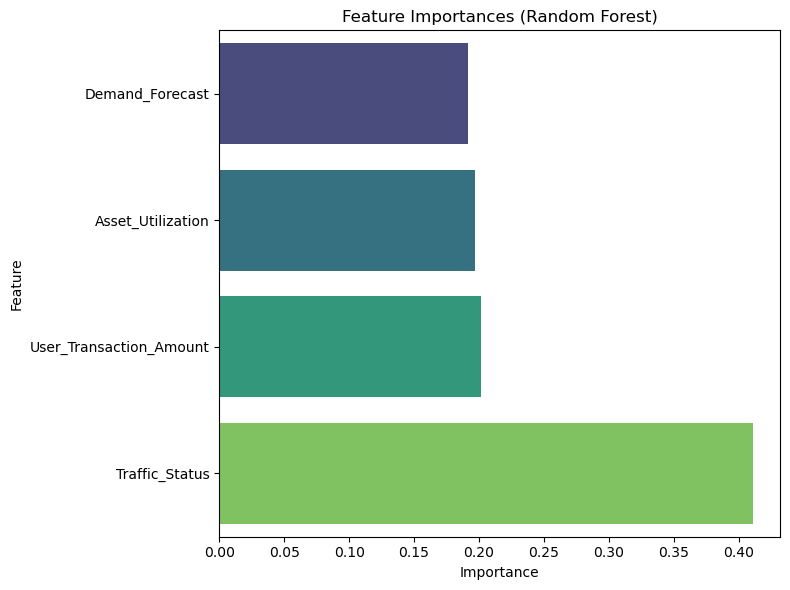

In [41]:
# Inspect the variables that are most important to the model
# ==============================================================================
display(rf.feature_importances_)
display(sum(rf.feature_importances_))
display(rf.feature_names_in_)

# Create a pariplot of the most important predictors
# ==============================================================================

feat_df = pd.DataFrame({
    'Feature': rf.feature_names_in_,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Performance evaluation
# ==============================================================================

# Predict
# ==============================================================================
y_pred = rf.predict(X_test)

# Accuracy
# ==============================================================================
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
# ==============================================================================
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Full classification report
# ==============================================================================
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Delay", "Delay"]))

Accuracy: 0.725

Confusion Matrix:
[[79 10]
 [45 66]]

Classification Report:
              precision    recall  f1-score   support

    No Delay       0.64      0.89      0.74        89
       Delay       0.87      0.59      0.71       111

    accuracy                           0.72       200
   macro avg       0.75      0.74      0.72       200
weighted avg       0.77      0.72      0.72       200



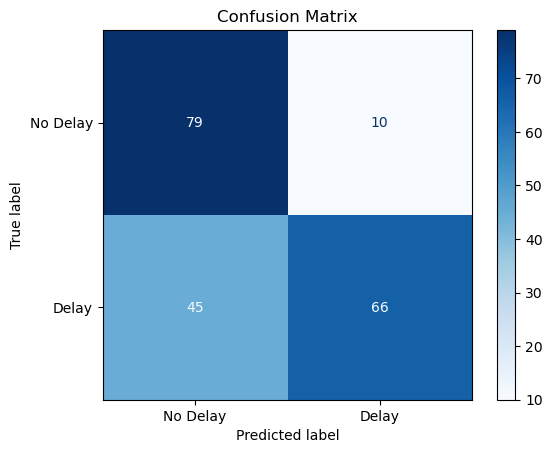

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Plot Confusion matrix
# ==============================================================================
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Delay", "Delay"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Optimization Insight
In this section, we leverage findings from the EDA and machine learning model to propose actionable strategies for reducing logistics delays.

### Key Operational Insights:

1. **Traffic-Aware Routing**
   - **Observation**: Heavy traffic routes had a 100% delay rate.
   - **Action**: Prioritize real-time traffic monitoring and dynamic routing to avoid predictable congestion patterns.

2. **Asset Performance Monitoring**
   - **Observation**: All asset utilization quartiles showed similar delay rates (~54%–58%), indicating no benefit from underutilization.
   - **Action**: Reallocate or replace underperforming assets rather than underusing them as a buffer strategy.

3. **Demand-Supply Mismatch**
   - **Observation**: Delays occur throughout the full range of demand forecasts, with no strong linear trend.
   - **Action**: While not a standalone predictor, demand forecast could still interact with other features (like inventory or temperature). Introduce demand smoothing or refine forecasting to support logistics planning.

These insights translate data into operations-focused recommendations that can directly improve efficiency and delay resilience in supply chain systems.

Traffic_Status
Clear     0.35061
Detour    0.35942
Heavy     1.00000
Name: Logistics_Delay, dtype: float64

/var/folders/p4/km2q7qsd1cl5b1h60220jf8w0000gn/T/ipykernel_51146/1067051773.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby(pd.qcut(df["Asset_Utilization"], 4))["Logistics_Delay"].mean())


Asset_Utilization
(59.999, 69.475]    0.576
(69.475, 79.25]     0.580
(79.25, 89.425]     0.548
(89.425, 100.0]     0.560
Name: Logistics_Delay, dtype: float64

<Axes: xlabel='Demand_Forecast', ylabel='Logistics_Delay'>

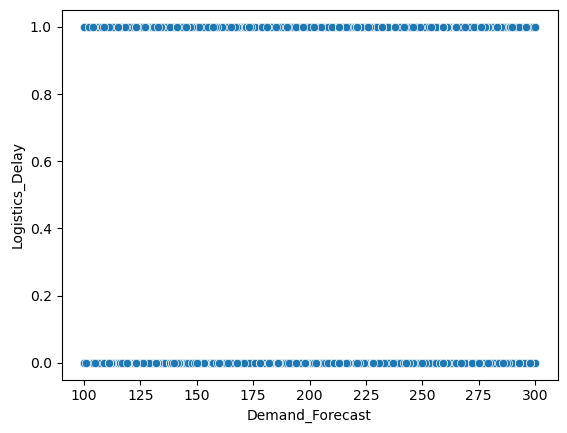

In [52]:
# Delay by Traffic Status
# ==============================================================================
display(df.groupby("Traffic_Status")["Logistics_Delay"].mean())

# Underperforming Assets
# ==============================================================================
display(df.groupby(pd.qcut(df["Asset_Utilization"], 4))["Logistics_Delay"].mean())

# Demand Supply Mismatch
# ==============================================================================
display(sns.scatterplot(x=df["Demand_Forecast"], y=df["Logistics_Delay"]))

We propose the following operational improvements:

### 1. Traffic-Aware Routing
- **Observation**: Heavy traffic leads to the highest delay rate (100%), compared to ~35% for clear/detour routes.
- **Recommendation**: Implement real-time traffic monitoring and dynamic rerouting to avoid high-delay routes.

### 2. Asset Performance Monitoring
- **Observation**: Logistics delays persist across all asset utilization quartiles (~54–58%).
- **Recommendation**: Underutilized assets do not reduce delays. Consider investing in maintenance, reallocation, or phasing out underperforming fleets.

### 3. Demand-Supply Mismatch
- **Observation**: While delay probability is not tightly tied to `Demand_Forecast` alone, higher forecasts cluster around 0 and 1 in delay outcome.
- **Recommendation**: Use demand smoothing and buffer stock strategies to minimize forecast-induced logistic strain.

These insights support data-driven decision-making for supply chain efficiency.